# 1. Standard Scaling

In [ ]:
`Standard Scaling` is a technique used to standardize the features of 
a dataset by removing the mean and scaling to unit variance. This is
particularly useful in machine learning algorithms that are sensitive to
the scale of the input data, such as Support Vector Machines (SVM) and 
K-Nearest Neighbors (KNN).
# formola of standard scaling:
 z = (x - u) / s
# where:
# z is the standardized value,
# x is the original value,
# u is the mean of the feature,
# s is the standard deviation of the feature.

In [29]:
# import libraries:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import load_iris
from sklearn.preprocessing import MaxAbsScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
#make an example dataframe:
data = {'age': [25, 30, 35, 40, 45],
        'weight': ['150', '160', '170', '180', '190'], 
        'height': [5.5, 6.0, 5.8, 5.9, 6.1]
        }
 #create a dataframe:       
df = pd.DataFrame(data)
df.head()  

,age,weight,height
0,25,150,5.5
1,30,160,6.0
2,35,170,5.8
3,40,180,5.9
4,45,190,6.1


In [11]:
# import the scaler:
scaler = StandardScaler()
 # fit the scaler to the data:
scaled_data = scaler.fit_transform(df)
# create a new dataframe with the scaled data:
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df.head()

,age,weight,height
0,-1.414214,-1.414214,-1.748315
1,-0.707107,-0.707107,0.679900
2,0.000000,0.000000,-0.291386
3,0.707107,0.707107,0.194257
4,1.414214,1.414214,1.165543


---

# Normalization:

In [15]:
from sklearn.preprocessing import Normalizer
data = [[4, 1, 2, 2],[1, 3, 9, 3],[5, 7, 5, 1]] 
normalizer = Normalizer()
normalized_data = normalizer.fit_transform(data)
normalized_data  
normalized_df = pd.DataFrame(normalized_data, columns=['A', 'B', 'C', 'D'])
normalized_df

,A,B,C,D
0,0.8,0.2,0.4,0.4
1,0.1,0.3,0.9,0.3
2,0.5,0.7,0.5,0.1


### Log Transformation:

In [16]:
# example dataset with skewed value:
data = {'value': [1, 2, 3, 4, 5, 6, 7, 8, 9, 100,2000.4000,50000,60000,70000]}
df = pd.DataFrame(data)
df.head()

,value
0,1.0
1,2.0
2,3.0
3,4.0
4,5.0


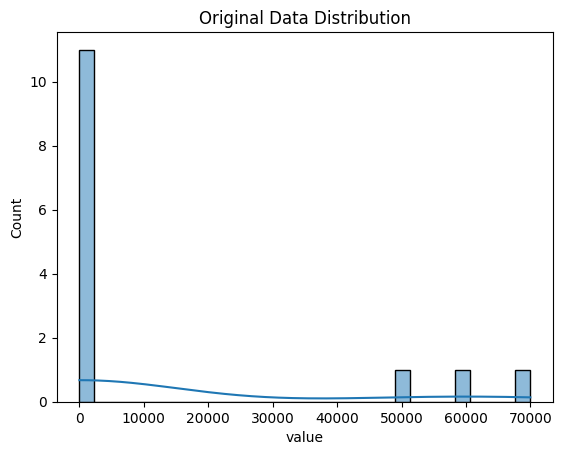

In [17]:
# visualize the skewed data:
sns.histplot(df['value'], bins=30, kde=True)
plt.title('Original Data Distribution')
plt.show()

In [18]:
# log transformation:
df['log_value'] = np.log1p(df['value'])
df.head()

,value,log_value
0,1.0,0.693147
1,2.0,1.098612
2,3.0,1.386294
3,4.0,1.609438
4,5.0,1.791759


In [19]:
df

,value,log_value
0,1.0,0.693147
1,2.0,1.098612
2,3.0,1.386294
3,4.0,1.609438
4,5.0,1.791759
5,6.0,1.945910
6,7.0,2.079442
7,8.0,2.197225
8,9.0,2.302585
9,100.0,4.615121


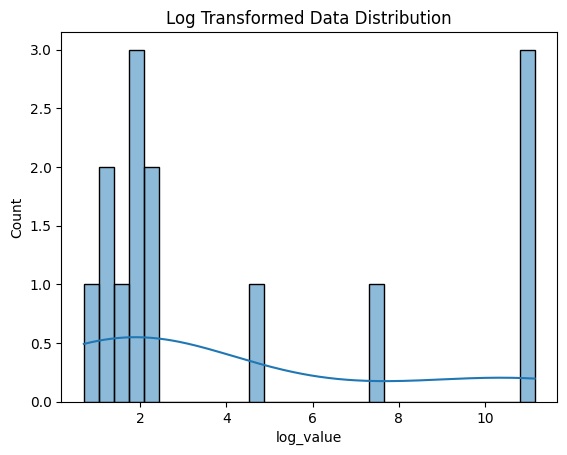

In [20]:
# visualize the log transformed data:
sns.histplot(df['log_value'], bins=30, kde=True)
plt.title('Log Transformed Data Distribution')
plt.show()

### min-max scaler:

In [27]:
# import the scaler:
scaler = MinMaxScaler()
 # fit the scaler to the data:
scaled_data = scaler.fit_transform(df)
# create a new dataframe with the scaled data:
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df.head()

,value,log_value
0,0.000000,0.000000
1,0.000014,0.038752
2,0.000029,0.066247
3,0.000043,0.087573
4,0.000057,0.104999


# Max ABS scaler:

In [ ]:
# import the scaler:
scaler = MaxAbsScaler()
 # fit the scaler to the data:
scaled_data = scaler.fit_transform(df)
# create a new dataframe with the scaled data:
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df.head() 

,value,log_value
0,0.000014,0.062131
1,0.000029,0.098475
2,0.000043,0.124262
3,0.000057,0.144263
4,0.000071,0.160606


---

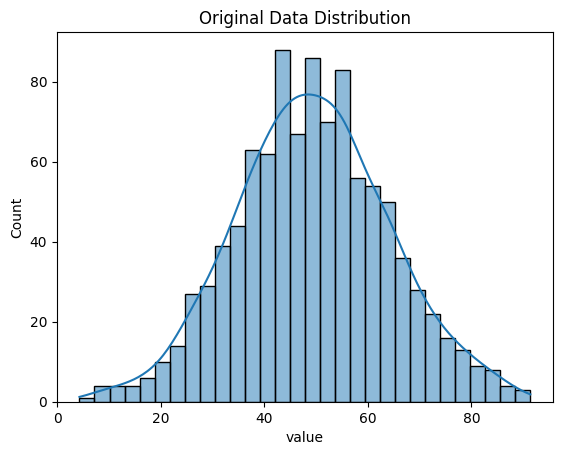

In [34]:
# make the random dataset is normally distributed:
np.random.seed(0)
data = np.random.normal(loc=50, scale=15, size=1000)
df = pd.DataFrame(data, columns=['value'])
df.head()
# visualize the original data:
sns.histplot(df['value'], bins=30, kde=True)
plt.title('Original Data Distribution')
plt.show()

In [41]:
df.head()

,value,boxcox_value,yeojohnson_value,quanyile_value
0,76.460785,1.819131,1.819287,1.773922
1,56.002358,0.455357,0.455335,0.480839
2,64.681070,1.035893,1.035941,1.066304
3,83.613398,2.292395,2.292618,2.225823
4,78.013370,1.922000,1.922170,1.837975


In [37]:
# transform the data using power transformation and quantile transformer:
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer

pt_boxcox = PowerTransformer(method='box-cox')
pt_yeo_johnson = PowerTransformer(method='yeo-johnson')

# box-cox k liay data must be positive:
df['boxcox_value'] = pt_boxcox.fit_transform(df[['value']])
df['yeojohnson_value'] = pt_yeo_johnson.fit_transform(df[['value']])
df['quanyile_value'] = QuantileTransformer(output_distribution='normal').fit_transform(df[['value']])

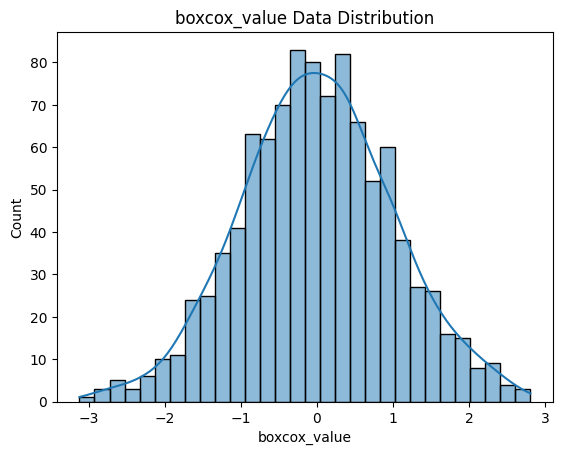

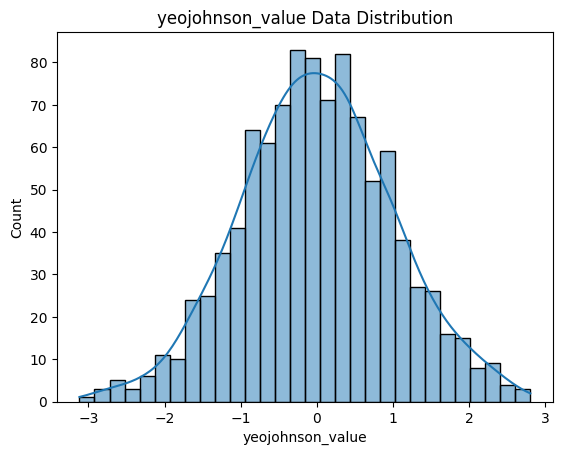

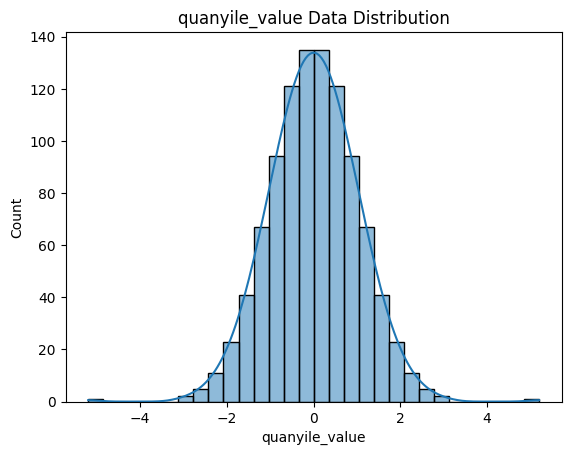

In [39]:
# visualize the nermally distributed data after transformation:
for col in ['boxcox_value', 'yeojohnson_value', 'quanyile_value']:
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'{col} Data Distribution')
    plt.show()